## 14 - Saving & Exporting Figures

### Why save figures?
You need to save charts to:
- Share in reports, presentations, emails
- Embed in websites or documents
- Include in research papers
- Store for future reference

### plt.savefig() - save to a file
```python
plt.savefig('chart.png')                    # PNG — raster, good for web
plt.savefig('chart.pdf')                    # PDF — vector, perfect for reports
plt.savefig('chart.svg')                    # SVG — scalable vector
plt.savefig('chart.jpg', quality=95)        # JPEG — photos, smaller size
```

### Key parameters
| Parameter | What it does | Recommended value |
|-----------|-------------|------------------|
| `dpi` | Resolution (dots per inch) | 120–150 for notebooks, 300 for print |
| `bbox_inches='tight'` | Remove extra white space around chart | Always use this |
| `transparent=True` | Transparent background (PNG only) | When embedding over coloured slides |
| `facecolor='white'` | Force white background | When saving dark-style charts |

### File format comparison
| Format | Type | Best for |
|--------|------|----------|
| PNG | Raster | Web, Jupyter, PowerPoint, emails |
| JPG | Raster | Photos, when file size is critical |
| PDF | Vector | Reports, LaTeX, professional printing |
| SVG | Vector | Web pages, edit in Illustrator/Inkscape |

### ⚠️ Critical Rule - Save BEFORE Show
```python
# ✅ CORRECT
plt.savefig('chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ❌ WRONG — savefig after show() saves a blank white image!
plt.show()
plt.savefig('chart.png')   # ← blank file!
```


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
subjects = ['Maths', 'Science', 'English', 'CompSci']
avgs     = [64.8, 68.2, 73.1, 70.5]
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

In [3]:
def make_chart():
    plt.figure(figsize=(8, 5))
    plt.bar(subjects, avgs, color=colors, edgecolor='white', width=0.55)
    for i, val in enumerate(avgs):
        plt.text(i, val + 0.3, f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)
    plt.axhline(sum(avgs)/len(avgs), color='navy', ls='--', lw=1.5,
                label=f'Avg = {sum(avgs)/len(avgs):.1f}')
    plt.title('Subject Average Scores', fontsize=14, fontweight='bold')
    plt.ylabel('Average Score')
    plt.ylim(55, 82)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

In [8]:
# Save in different formats
formats = [('png',''), ('pdf',''), ('svg','')]
for fmt, _ in formats:
    make_chart()
    path = f'subject_avgs.{fmt}'
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    plt.close()
    size = os.path.getsize(path) / 1024
    print(f'Saved {fmt.upper()}: {path}  ({size:.1f} KB)')

Saved PNG: subject_avgs.png  (24.3 KB)
Saved PDF: subject_avgs.pdf  (22.4 KB)
Saved SVG: subject_avgs.svg  (40.9 KB)


In [9]:
# Different DPI comparison 
print('DPI comparison (same chart, different quality):')
for dpi in [72, 120, 150, 300]:
    make_chart()
    path = f'dpi_{dpi}.png'
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.close()
    size = os.path.getsize(path) / 1024
    print(f'  DPI {dpi:4d} → {size:6.1f} KB  (use 120-150 for notebooks, 300 for print)')

DPI comparison (same chart, different quality):
  DPI   72 →   15.3 KB  (use 120-150 for notebooks, 300 for print)
  DPI  120 →   28.7 KB  (use 120-150 for notebooks, 300 for print)
  DPI  150 →   37.9 KB  (use 120-150 for notebooks, 300 for print)
  DPI  300 →   85.9 KB  (use 120-150 for notebooks, 300 for print)


In [11]:
# Transparent background
make_chart()
plt.savefig('transparent.png', bbox_inches='tight', transparent=True)
plt.close()
print('Saved transparent PNG - background is clear when placed on slides.')

Saved transparent PNG - background is clear when placed on slides.


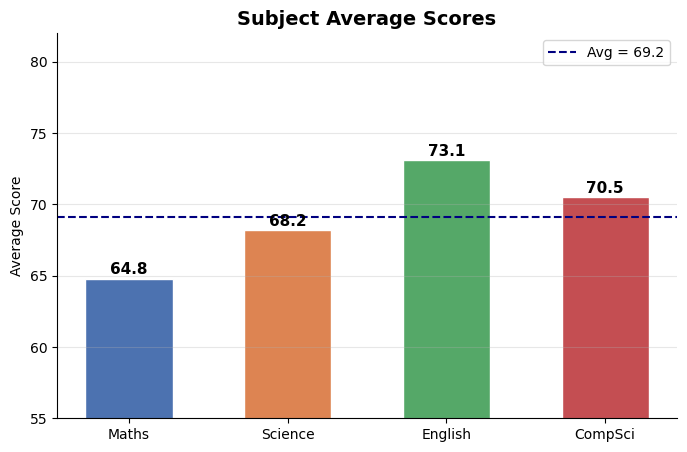

In [12]:
# Show one final version
make_chart()
plt.savefig('s14_final.png', dpi=150, bbox_inches='tight')
plt.show()